# Simple ANN for Sentiment Analysis
Task 1.1 (Model 1): building a feedforward ANN to classify Amazon reviews as positive/negative.

**Approach:** To start with the given data and then improve with more data. Running 3 experiments:
1. **1K reviews** - small file (`amazon_cells_labelled.txt`)
2. **25K reviews** - larger local file (`amazon_cells_labelled_LARGE_25K.txt`)
3. **Full 3.6M reviews** - complete Amazon Polarity from Hugging Face

ANN has no concept of word order. Text is represented as a TF-IDF vector (bag-of-words), which the network processes as a flat feature vector. This is simpler and faster but loses sequential context - "not good" looks the same as "good not".

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay
from datasets import load_dataset
import json, time, os, re, gc, random

from config import SEED, NUM_LABELS, LABEL_MAP
from data_pipeline import set_seed, clean_text

set_seed(SEED)

# Device setup — supports CUDA or CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("device:", device)

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda


## Model & helper functions
The `SimpleANN` takes a TF-IDF vector (fixed-size bag-of-words) as input, passes it through two hidden layers with BatchNorm, ReLU, and Dropout, then outputs class logits.

The ANN treats the entire review as a single feature vector - much simpler but blind to word order.

In [2]:
class SimpleANN(nn.Module):
    def __init__(self, input_dim, hidden1, hidden2, num_classes, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.BatchNorm1d(hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.BatchNorm1d(hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, num_classes),
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
# Hyperparameters — kept consistent across all 3 experiments for a fair comparison
MAX_FEATURES  = 50_000   # TF-IDF vocabulary size
HIDDEN1       = 512      
HIDDEN2       = 256
DROPOUT       = 0.3      
LR            = 1e-3     
WEIGHT_DECAY  = 1e-5     
CLIP_NORM     = 1.0      
BATCH_SIZE    = 256      
NUM_EPOCHS    = 100      
PATIENCE      = 5        

In [ ]:
def load_local_file(filepath):
    texts, labels = [], []
    with open(filepath, encoding="utf-8") as f:
        for line in f:
            parts = line.strip().rsplit('\t', 1)
            if len(parts) == 2:
                texts.append(clean_text(parts[0]))
                labels.append(int(parts[1]))
    return texts, labels


def build_tfidf(train_texts, max_features=MAX_FEATURES):
    """Fit TF-IDF on training data only — no leakage into val/test."""
    vectorizer = TfidfVectorizer(
        analyzer='word',
        ngram_range=(1, 2),
        max_features=max_features,
        max_df=0.95,
        min_df=2,
        use_idf=True,
        norm='l2',
    )
    vectorizer.fit(train_texts)
    return vectorizer


def texts_to_sparse(texts, vectorizer):
    """Transform texts to TF-IDF sparse matrix."""
    return vectorizer.transform(texts)  #shape (n, max_features)


class ANNDataset(Dataset):
    def __init__(self, X, y_list):
        self.X = X
        self.y = torch.tensor(y_list, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        # Convert a single sparse row to a dense 1-D tensor on demand
        x = torch.from_numpy(self.X[idx].toarray()).float().squeeze(0)
        return x, self.y[idx]


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, correct, total = 0, 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(X)
        loss = criterion(out, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), CLIP_NORM)
        optimizer.step()
        running_loss += loss.item() * y.size(0)
        correct += (out.argmax(1) == y).sum().item()
        total += y.size(0)
    return running_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            out = model(X)
            loss = criterion(out, y)
            running_loss += loss.item() * y.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)
    return running_loss / total, correct / total

In [ ]:
def run_experiment(name, splits, save_path):
    train_texts, train_labels = splits['train']['texts'], splits['train']['labels']
    val_texts,   val_labels   = splits['val']['texts'],   splits['val']['labels']
    test_texts,  test_labels  = splits['test']['texts'],  splits['test']['labels']

    print(f"\n{'-'*50}")
    print(f"  {name}")
    print(f"  train={len(train_texts):,}  val={len(val_texts):,}  test={len(test_texts):,}")
    print(f"{'-'*50}")

    # TF-IDF fitted on train only
    vectorizer = build_tfidf(train_texts)
    vocab_size  = len(vectorizer.vocabulary_)
    print(f"  vocab (TF-IDF features): {vocab_size:,}")

    train_X = texts_to_sparse(train_texts, vectorizer)
    val_X   = texts_to_sparse(val_texts,   vectorizer)
    test_X  = texts_to_sparse(test_texts,  vectorizer)

    train_loader = DataLoader(ANNDataset(train_X, train_labels), batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
    val_loader   = DataLoader(ANNDataset(val_X,   val_labels),   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    test_loader  = DataLoader(ANNDataset(test_X,  test_labels),  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    input_dim = train_X.shape[1]
    model = SimpleANN(input_dim, HIDDEN1, HIDDEN2, NUM_LABELS, DROPOUT).to(device)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"  parameters: {total_params:,}")

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "lr": []}
    best_val_acc      = 0.0
    epochs_no_improve = 0

    for epoch in range(NUM_EPOCHS):
        start = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss,   val_acc   = evaluate(model, val_loader, criterion)
        scheduler.step(val_loss)
        lr = optimizer.param_groups[0]['lr']

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["lr"].append(lr)

        elapsed = time.time() - start
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} ({elapsed:.1f}s) | "
              f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | lr={lr:.6f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            epochs_no_improve = 0
            torch.save(model.state_dict(), save_path)
            print(f"  -> saved (val_acc={val_acc:.4f})")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= PATIENCE:
                print(f"\nEarly stopping at epoch {epoch+1}")
                break

    actual_epochs = len(history["train_loss"])

    # Load best checkpoint and evaluate on test set
    model.load_state_dict(torch.load(save_path, map_location=device))
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for X, y in test_loader:
            X = X.to(device)
            all_preds.extend(model(X).argmax(1).cpu().numpy())
            all_true.extend(y.numpy())

    test_acc = accuracy_score(all_true, all_preds)
    prec, rec, f1, _ = precision_recall_fscore_support(all_true, all_preds, average="binary")
    print(f"\nTest Acc: {test_acc:.4f}  F1: {f1:.4f}")

    # Training curves
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(name, fontsize=13, fontweight='bold')
    ep = range(1, actual_epochs + 1)

    axes[0].plot(ep, history["train_loss"], label="train", marker='o', markersize=3)
    axes[0].plot(ep, history["val_loss"],   label="val",   marker='o', markersize=3)
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].set_title("Loss")
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(ep, history["train_acc"], label="train", marker='o', markersize=3)
    axes[1].plot(ep, history["val_acc"],   label="val",   marker='o', markersize=3)
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].set_title("Accuracy")
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    axes[2].plot(ep, history["lr"], color="green", marker='o', markersize=3)
    axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("LR"); axes[2].set_title("Learning Rate")
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return {
        "name": name,
        "dataset_size": len(train_texts) + len(val_texts) + len(test_texts),
        "train_size":   len(train_texts),
        "vocab_size":   vocab_size,
        "total_params": total_params,
        "actual_epochs": actual_epochs,
        "best_val_acc": best_val_acc,
        "test_accuracy": test_acc, "test_precision": prec, "test_recall": rec, "test_f1": f1,
        "history": history,
        "test_preds": np.array(all_preds), "test_labels": np.array(all_true),
        "model": model, "vectorizer": vectorizer,
    }

all_results = []

## Experiment 1: Small dataset (1,000 reviews)
Starting with the small file provided by the course. Only 1,000 reviews - train set is just 800. TF-IDF vocabulary will be tiny which limits the model, but this is the baseline the lab asks us to establish first.


--------------------------------------------------
  1K local dataset
  train=800  val=100  test=100
--------------------------------------------------
  vocab (TF-IDF features): 1,464
  parameters: 883,458
Epoch 1/100 (0.5s) | train_loss=0.6711 train_acc=0.5800 | val_loss=0.6903 val_acc=0.6800 | lr=0.001000
  -> saved (val_acc=0.6800)
Epoch 2/100 (0.1s) | train_loss=0.2890 train_acc=0.9263 | val_loss=0.6832 val_acc=0.5300 | lr=0.001000
Epoch 3/100 (0.1s) | train_loss=0.1124 train_acc=0.9925 | val_loss=0.6704 val_acc=0.5600 | lr=0.001000
Epoch 4/100 (0.1s) | train_loss=0.0425 train_acc=0.9962 | val_loss=0.6574 val_acc=0.5400 | lr=0.001000
Epoch 5/100 (0.1s) | train_loss=0.0194 train_acc=0.9975 | val_loss=0.6424 val_acc=0.5600 | lr=0.001000
Epoch 6/100 (0.1s) | train_loss=0.0111 train_acc=0.9988 | val_loss=0.6309 val_acc=0.5800 | lr=0.001000

Early stopping at epoch 6

Test Acc: 0.7800  F1: 0.7800


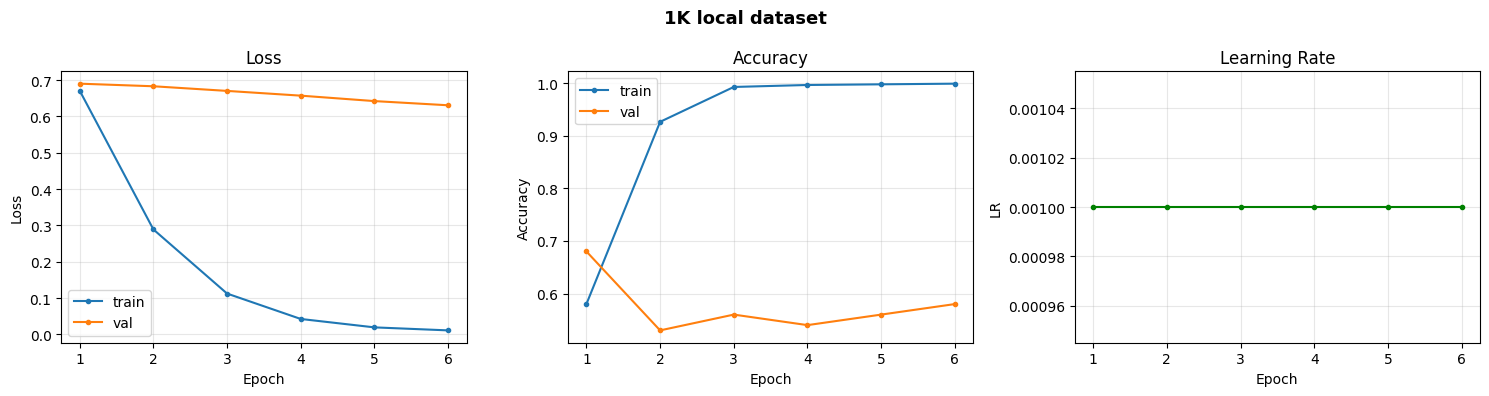

In [ ]:
texts_1k, labels_1k = load_local_file("data/amazon_cells_labelled.txt")

# 80/10/10 split
train_t, temp_t, train_l, temp_l = train_test_split(
    texts_1k, labels_1k, test_size=0.2, random_state=SEED, stratify=labels_1k)
val_t, test_t, val_l, test_l = train_test_split(
    temp_t, temp_l, test_size=0.5, random_state=SEED, stratify=temp_l)

splits_1k = {
    "train": {"texts": train_t, "labels": train_l},
    "val":   {"texts": val_t,   "labels": val_l},
    "test":  {"texts": test_t,  "labels": test_l},
}

result_1k = run_experiment("1K local dataset", splits_1k, "ann_1k.pt")
all_results.append(result_1k)

## Experiment 2: Medium dataset (25,000 reviews)
Scaling up with the larger local file. 25x more data means a much richer TF-IDF vocabulary and more training examples - expecting a solid improvement.


--------------------------------------------------
  25K local dataset
  train=20,000  val=2,500  test=2,500
--------------------------------------------------
  vocab (TF-IDF features): 40,308
  parameters: 20,771,586
Epoch 1/100 (10.0s) | train_loss=0.3194 train_acc=0.8614 | val_loss=0.2647 val_acc=0.8952 | lr=0.001000
  -> saved (val_acc=0.8952)
Epoch 2/100 (8.9s) | train_loss=0.0750 train_acc=0.9737 | val_loss=0.3846 val_acc=0.8796 | lr=0.001000
Epoch 3/100 (12.0s) | train_loss=0.0133 train_acc=0.9967 | val_loss=0.4806 val_acc=0.8784 | lr=0.001000
Epoch 4/100 (9.6s) | train_loss=0.0027 train_acc=0.9993 | val_loss=0.5456 val_acc=0.8776 | lr=0.000500
Epoch 5/100 (7.2s) | train_loss=0.0005 train_acc=1.0000 | val_loss=0.5561 val_acc=0.8768 | lr=0.000500
Epoch 6/100 (6.9s) | train_loss=0.0003 train_acc=1.0000 | val_loss=0.5665 val_acc=0.8764 | lr=0.000500

Early stopping at epoch 6

Test Acc: 0.8952  F1: 0.9150


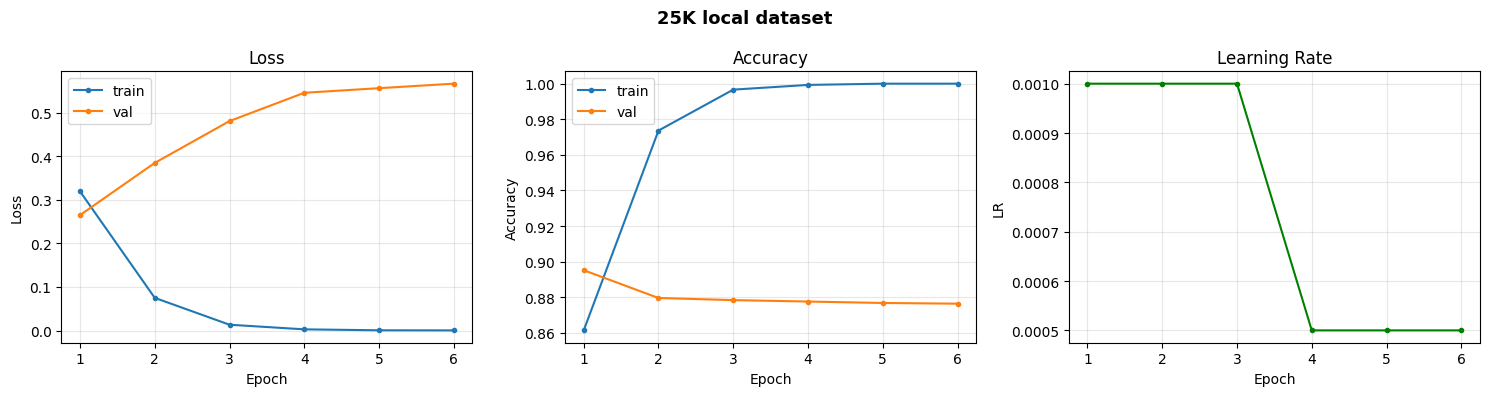

In [7]:
texts_25k, labels_25k = load_local_file("data/amazon_cells_labelled_LARGE_25K.txt")

train_t, temp_t, train_l, temp_l = train_test_split(
    texts_25k, labels_25k, test_size=0.2, random_state=SEED, stratify=labels_25k)
val_t, test_t, val_l, test_l = train_test_split(
    temp_t, temp_l, test_size=0.5, random_state=SEED, stratify=temp_l)

splits_25k = {
    "train": {"texts": train_t, "labels": train_l},
    "val":   {"texts": val_t,   "labels": val_l},
    "test":  {"texts": test_t,  "labels": test_l},
}

result_25k = run_experiment("25K local dataset", splits_25k, "ann_25k.pt")
all_results.append(result_25k)

## Experiment 3: Full dataset (3.6M reviews)
Using the complete Amazon Polarity dataset from Hugging Face. This is the final model — results will feed into the Task 1.3 comparison against Bi-LSTM and Transformer.


--------------------------------------------------
  Full 3.6M (HF)
  train=2,880,000  val=360,000  test=360,000
--------------------------------------------------
  vocab (TF-IDF features): 50,000
  parameters: 25,733,890
Epoch 2/100 (2440.3s) | train_loss=0.1943 train_acc=0.9234 | val_loss=0.1895 val_acc=0.9249 | lr=0.001000
  -> saved (val_acc=0.9249)
Epoch 3/100 (1407.7s) | train_loss=0.1846 train_acc=0.9281 | val_loss=0.1878 val_acc=0.9260 | lr=0.001000
  -> saved (val_acc=0.9260)
Epoch 4/100 (1481.5s) | train_loss=0.1786 train_acc=0.9307 | val_loss=0.1871 val_acc=0.9257 | lr=0.001000
Epoch 5/100 (1526.7s) | train_loss=0.1744 train_acc=0.9324 | val_loss=0.1872 val_acc=0.9260 | lr=0.001000
  -> saved (val_acc=0.9260)
Epoch 6/100 (1632.4s) | train_loss=0.1716 train_acc=0.9339 | val_loss=0.1886 val_acc=0.9251 | lr=0.001000
Epoch 7/100 (2191.2s) | train_loss=0.1698 train_acc=0.9346 | val_loss=0.1872 val_acc=0.9262 | lr=0.000500
  -> saved (val_acc=0.9262)
Epoch 8/100 (1290.2s) | trai

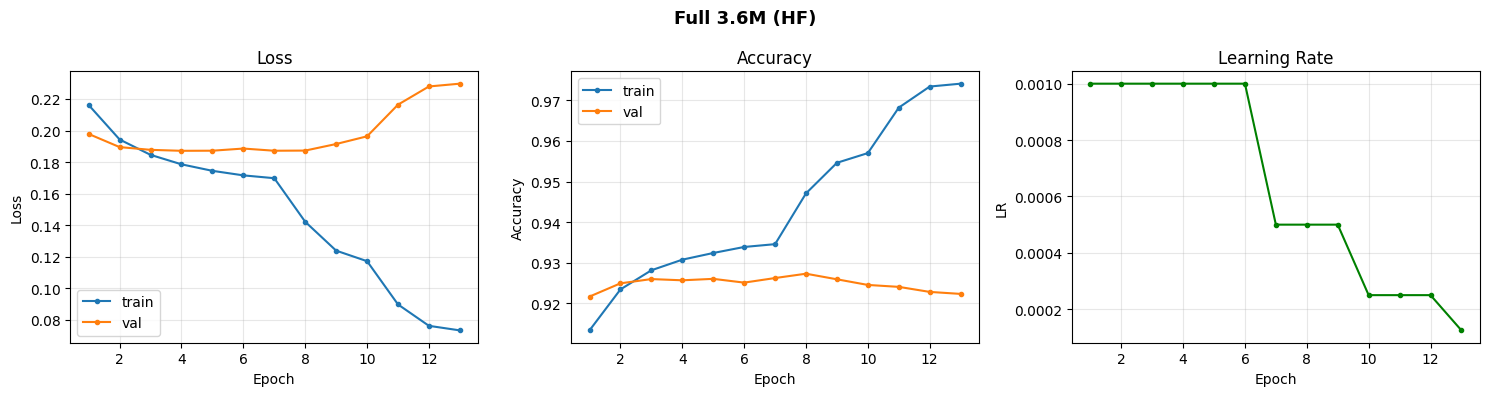

In [8]:
# Load full Amazon Polarity from Hugging Face (subset_size=None = all 3.6M rows)
from data_pipeline import load_and_split

splits_full = load_and_split(subset_size=None)

result_full = run_experiment("Full 3.6M (HF)", splits_full, "best_ann.pt")
all_results.append(result_full)

## Data size comparison
Comparing all 3 runs to see how performance scales with dataset size.


Dataset                    Size      Train   Vocab  Epochs  Test Acc      F1
----------------------------------------------------------------------------
1K local dataset          1,000        800   1,464       6    0.7800  0.7800
25K local dataset        25,000     20,000  40,308       6    0.8952  0.9150
Full 3.6M (HF)         3,600,000  2,880,000  50,000      13    0.9283  0.9284


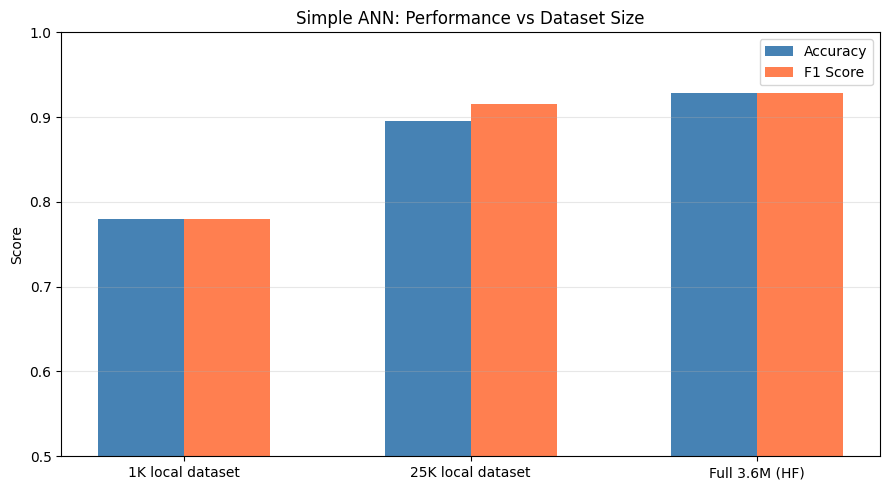

In [9]:
# Summary table
print(f"\n{'Dataset':<22} {'Size':>8} {'Train':>10} {'Vocab':>7} {'Epochs':>7} {'Test Acc':>9} {'F1':>7}")
print("-" * 76)
for r in all_results:
    print(f"{r['name']:<22} {r['dataset_size']:>8,} {r['train_size']:>10,} "
          f"{r['vocab_size']:>7,} {r['actual_epochs']:>7} {r['test_accuracy']:>9.4f} {r['test_f1']:>7.4f}")

# Bar chart
fig, ax = plt.subplots(figsize=(9, 5))
names = [r['name'] for r in all_results]
accs  = [r['test_accuracy'] for r in all_results]
f1s   = [r['test_f1']       for r in all_results]

x = np.arange(len(names))
w = 0.3
ax.bar(x - w/2, accs, w, label='Accuracy', color='steelblue')
ax.bar(x + w/2, f1s,  w, label='F1 Score', color='coral')
ax.set_ylabel('Score')
ax.set_title('Simple ANN: Performance vs Dataset Size')
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0.5, 1.0)
plt.tight_layout()
plt.show()

## Final evaluation (best model)
Loading the best model (full dataset) for a detailed look at the confusion matrix.

Final Test Results (Full 3.6M (HF)):
  Accuracy:  0.9283
  Precision: 0.9262
  Recall:    0.9307
  F1 Score:  0.9284


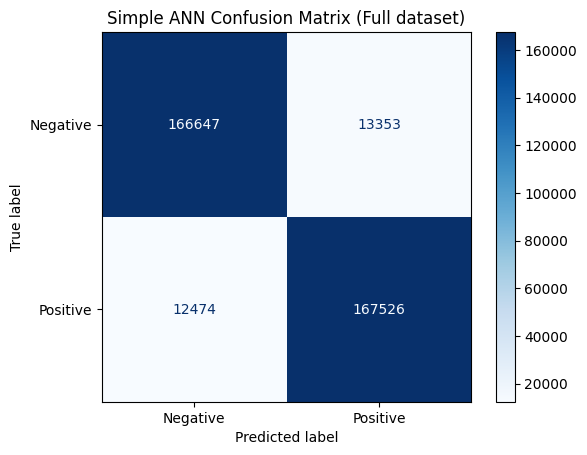

FP: 13,353  FN: 12,474


In [10]:
best = all_results[-1]

print(f"Final Test Results ({best['name']}):")
print(f"  Accuracy:  {best['test_accuracy']:.4f}")
print(f"  Precision: {best['test_precision']:.4f}")
print(f"  Recall:    {best['test_recall']:.4f}")
print(f"  F1 Score:  {best['test_f1']:.4f}")

cm   = confusion_matrix(best['test_labels'], best['test_preds'])
disp = ConfusionMatrixDisplay(cm, display_labels=["Negative", "Positive"])
disp.plot(cmap="Blues")
plt.title("Simple ANN Confusion Matrix (Full dataset)")
plt.show()

print(f"FP: {cm[0][1]:,}  FN: {cm[1][0]:,}")

## Save results for Task 1.3
Saving metrics and history to `ann_results.json` - so the comparison notebook can load both side-by-side.

In [11]:
best = all_results[-1]

results = {
    "model": "Simple ANN",
    "dataset_size":   best['dataset_size'],
    "train_size":     best['train_size'],
    "vocab_size":     best['vocab_size'],
    "hidden1":        HIDDEN1,
    "hidden2":        HIDDEN2,
    "max_features":   MAX_FEATURES,
    "total_params":   best['total_params'],
    "max_epochs":     NUM_EPOCHS,
    "actual_epochs":  best['actual_epochs'],
    "early_stopping_patience": PATIENCE,
    "best_val_acc":   best['best_val_acc'],
    "test_accuracy":  best['test_accuracy'],
    "test_precision": best['test_precision'],
    "test_recall":    best['test_recall'],
    "test_f1":        best['test_f1'],
    "history":        best['history'],
    # data size comparison across all 3 experiments
    "data_size_comparison": [
        {"name": r['name'], "dataset_size": r['dataset_size'],
         "test_accuracy": r['test_accuracy'], "test_f1": r['test_f1']}
        for r in all_results
    ],
}

with open("ann_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("saved to ann_results.json")

saved to ann_results.json
